### IPL 2022 Capstone Project

**The Indian Premier League (IPL) is a professional T20 cricket league in India, featuring franchises representing cities. This project explores IPL 2022 match-level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics.**

**These are some of the important columns that we'll focus on for meaningful insights in this project.**

**column names: Variable Type**
* date : string  
* venue : string  
* stage : string  
* team1 : string  
* team2 : string  
* toss_winner : string  
* toss_decision : string  
* first_ings_score : integer  
* second_ings_score : integer  
* match_winner : string  
* won_by : string  
* margin : integer  
* player_of_the_match : string  
* top_scorer : string  
* highscore : integer  
* best_bowling : string  
* best_bowling_fgure : string  
gure : string  


### Loading the Libraries and Dataset

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings("ignore")

df = pd.read_csv('matches.csv')

# Duplicate columns to support both original matches.csv and Capstone expected names
df['match_winner'] = df['winner']
df['won_by'] = df['result']
df['margin'] = df['result_margin']
df['player_of_the_match'] = df['player_of_match']

# Create dummy columns for columns missing from matches.csv to avoid KeyErrors
if 'top_scorer' not in df.columns:
    df['top_scorer'] = 'Unknown'
if 'highscore' not in df.columns:
    df['highscore'] = 0
if 'best_bowling' not in df.columns:
    df['best_bowling'] = 'Unknown'
if 'best_bowling_figure' not in df.columns:
    df['best_bowling_figure'] = '0--0'

df.head()


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,umpire1,umpire2,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,...,Asad Rauf,RE Koertzen,Kolkata Knight Riders,runs,140.0,BB McCullum,Unknown,0,Unknown,0--0
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,...,MR Benson,SL Shastri,Chennai Super Kings,runs,33.0,MEK Hussey,Unknown,0,Unknown,0--0
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,...,Aleem Dar,GA Pratapkumar,Delhi Daredevils,wickets,9.0,MF Maharoof,Unknown,0,Unknown,0--0
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,...,SJ Davis,DJ Harper,Royal Challengers Bangalore,wickets,5.0,MV Boucher,Unknown,0,Unknown,0--0
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,...,BF Bowden,K Hariharan,Kolkata Knight Riders,wickets,5.0,DJ Hussey,Unknown,0,Unknown,0--0


### Basic Information

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   1095 non-null   int64  
 1   season               1095 non-null   object 
 2   city                 1044 non-null   object 
 3   date                 1095 non-null   object 
 4   match_type           1095 non-null   object 
 5   player_of_match      1090 non-null   object 
 6   venue                1095 non-null   object 
 7   team1                1095 non-null   object 
 8   team2                1095 non-null   object 
 9   toss_winner          1095 non-null   object 
 10  toss_decision        1095 non-null   object 
 11  winner               1090 non-null   object 
 12  result               1095 non-null   object 
 13  result_margin        1076 non-null   float64
 14  target_runs          1092 non-null   float64
 15  target_overs         1092 non-null   f

Check the size of rows and columns of the dataset

In [3]:
print(f"your rows are {df.shape[0]} and your columns are {df.shape[1]}")

your rows are 1095 and your columns are 28


Now let's see how many columns have null values in total.

In [4]:
df.isnull().sum()

id                        0
season                    0
city                     51
date                      0
match_type                0
player_of_match           5
venue                     0
team1                     0
team2                     0
toss_winner               0
toss_decision             0
winner                    5
result                    0
result_margin            19
target_runs               3
target_overs              3
super_over                0
method                 1074
umpire1                   0
umpire2                   0
match_winner              5
won_by                    0
margin                   19
player_of_the_match       5
top_scorer                0
highscore                 0
best_bowling              0
best_bowling_figure       0
dtype: int64

**Now, Here comes some Basic Questions**

1. Which team won the most matches?

Text(0.5, 1.0, 'Most match win by team ')

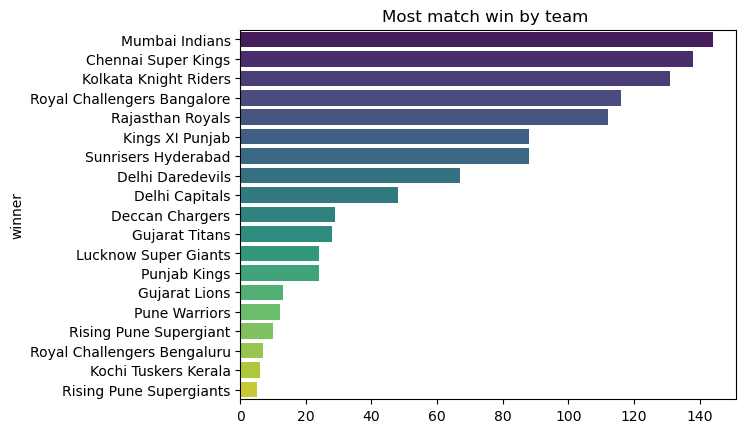

In [5]:
match_wins = df['winner'].value_counts()
sns.barplot(y = match_wins.index,x = match_wins.values,palette='viridis')
plt.title("Most match win by team ")

2. Toss Decision Trends

Text(0.5, 1.0, 'Toss Decision Trends ')

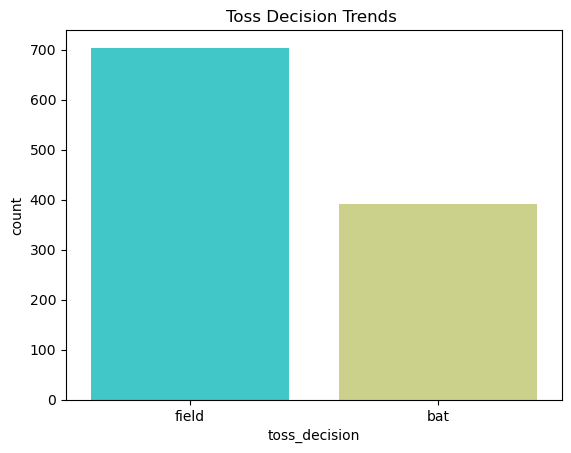

In [6]:
sns.countplot(x = df['toss_decision'],palette='rainbow')
plt.title("Toss Decision Trends ")

3. Toss Winner vs Match Winner

In [7]:
count = df[df['toss_winner'] == df['winner']]['id'].count()
percentage = (count *100)/df.shape[0]
print('percentage of winners :', percentage.round(2))

percentage of winners : 50.59


4. How do teams win? (Runs vs Wickets)

Text(0.5, 1.0, 'Won by')

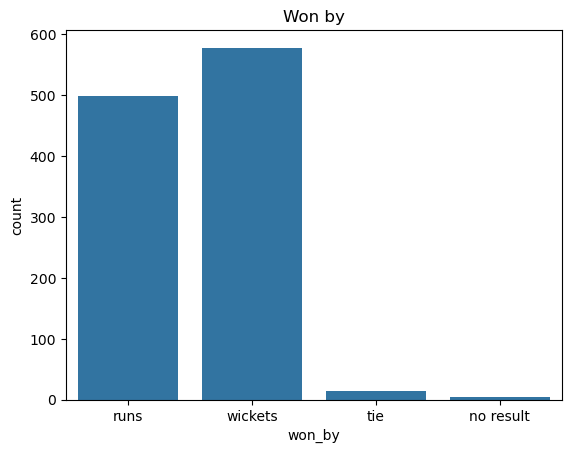

In [8]:
sns.countplot(x = df['won_by'])
plt.title("Won by")

###  Key Player Performances

1 Most "Player of the Match" Awards

In [9]:
count = df['player_of_match'].value_counts().head(10)


Text(0.5, 1.0, 'Top 10 plauers with man of the match')

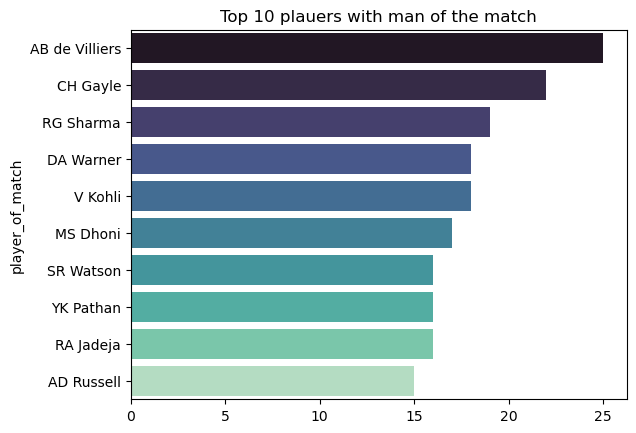

In [10]:
sns.barplot(x = count.values , y = count.index,palette='mako')
plt.title("Top 10 plauers with man of the match")

2 Top Scorers

In [11]:
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,umpire1,umpire2,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,...,Asad Rauf,RE Koertzen,Kolkata Knight Riders,runs,140.0,BB McCullum,Unknown,0,Unknown,0--0
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,...,MR Benson,SL Shastri,Chennai Super Kings,runs,33.0,MEK Hussey,Unknown,0,Unknown,0--0
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,...,Aleem Dar,GA Pratapkumar,Delhi Daredevils,wickets,9.0,MF Maharoof,Unknown,0,Unknown,0--0
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,...,SJ Davis,DJ Harper,Royal Challengers Bangalore,wickets,5.0,MV Boucher,Unknown,0,Unknown,0--0
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,...,BF Bowden,K Hariharan,Kolkata Knight Riders,wickets,5.0,DJ Hussey,Unknown,0,Unknown,0--0


In [12]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
high

top_scorer
Unknown    0
Name: highscore, dtype: int64

<Axes: ylabel='top_scorer'>

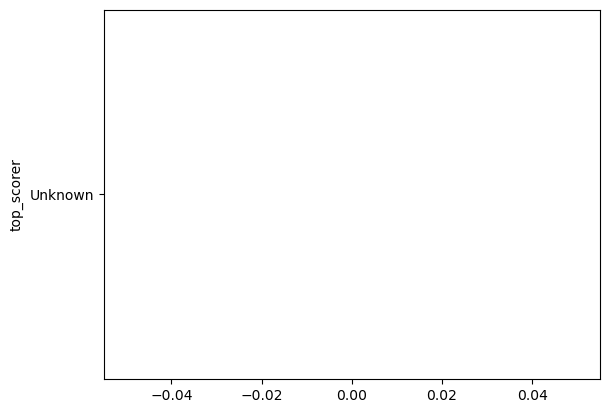

In [13]:
high.plot(kind = 'barh')

10 Best Bowling Figures

In [14]:
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,umpire1,umpire2,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,...,Asad Rauf,RE Koertzen,Kolkata Knight Riders,runs,140.0,BB McCullum,Unknown,0,Unknown,0--0
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,...,MR Benson,SL Shastri,Chennai Super Kings,runs,33.0,MEK Hussey,Unknown,0,Unknown,0--0
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,...,Aleem Dar,GA Pratapkumar,Delhi Daredevils,wickets,9.0,MF Maharoof,Unknown,0,Unknown,0--0
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,...,SJ Davis,DJ Harper,Royal Challengers Bangalore,wickets,5.0,MV Boucher,Unknown,0,Unknown,0--0
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,...,BF Bowden,K Hariharan,Kolkata Knight Riders,wickets,5.0,DJ Hussey,Unknown,0,Unknown,0--0


<Axes: ylabel='best_bowling'>

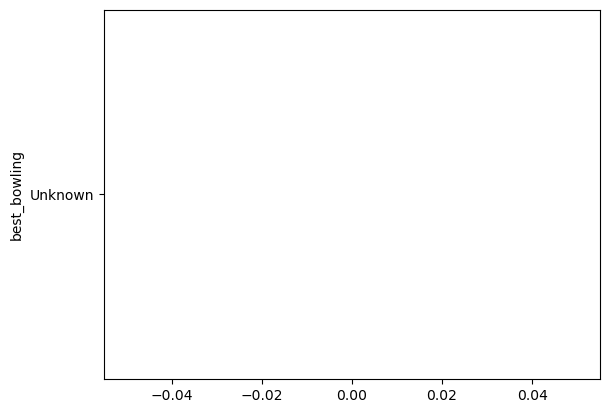

In [15]:
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x :x.split('--')[0])
df['highest_wickets'] = df['highest_wickets'].astype(int)
top_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
top_bowlers.plot(kind = 'barh')

###  Venue Analysis

Most Matches Played by Venue

In [16]:
venue_count = df['venue'].value_counts()
venue_count

venue
Eden Gardens                                                             77
Wankhede Stadium                                                         73
M Chinnaswamy Stadium                                                    65
Feroz Shah Kotla                                                         60
Rajiv Gandhi International Stadium, Uppal                                49
MA Chidambaram Stadium, Chepauk                                          48
Sawai Mansingh Stadium                                                   47
Dubai International Cricket Stadium                                      46
Wankhede Stadium, Mumbai                                                 45
Punjab Cricket Association Stadium, Mohali                               35
Sheikh Zayed Stadium                                                     29
Sharjah Cricket Stadium                                                  28
MA Chidambaram Stadium, Chepauk, Chennai                                 28
Narend

<Axes: ylabel='venue'>

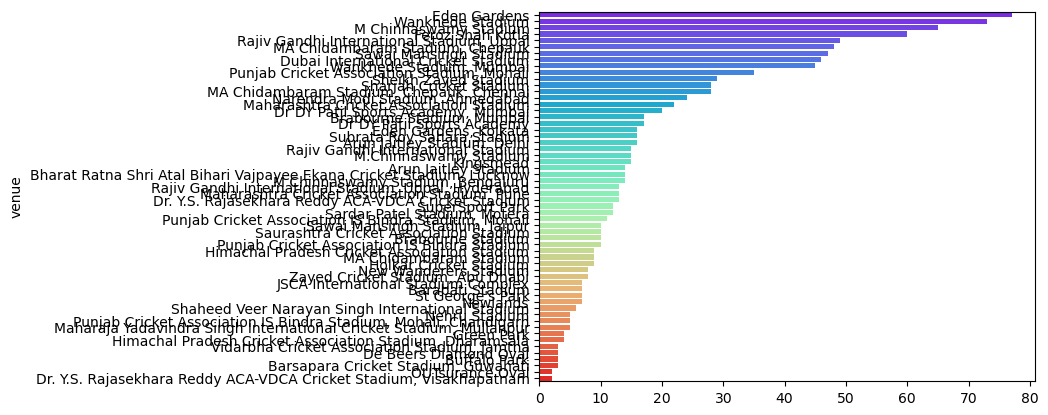

In [17]:
sns.barplot(y = venue_count.index,x = venue_count.values,palette='rainbow')

### Custom Questions & Insights
Q1: Who won the highest margin by runs?

In [18]:
df[df['won_by'] == 'Runs'].sort_values(by = 'margin',ascending=False).head(1)[['match_winner','margin']]

,match_winner,margin


Q2: Which player had the highest individual score?

In [19]:
df[df['highscore'] == df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
0,Unknown,0
1,Unknown,0
2,Unknown,0
3,Unknown,0
4,Unknown,0
...,...,...
1090,Unknown,0
1091,Unknown,0
1092,Unknown,0
1093,Unknown,0


Q3: Which bowler had the best bowling figures?

In [20]:
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,umpire2,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wickets
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,...,RE Koertzen,Kolkata Knight Riders,runs,140.0,BB McCullum,Unknown,0,Unknown,0--0,0
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,...,SL Shastri,Chennai Super Kings,runs,33.0,MEK Hussey,Unknown,0,Unknown,0--0,0
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,...,GA Pratapkumar,Delhi Daredevils,wickets,9.0,MF Maharoof,Unknown,0,Unknown,0--0,0
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,...,DJ Harper,Royal Challengers Bangalore,wickets,5.0,MV Boucher,Unknown,0,Unknown,0--0,0
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,...,K Hariharan,Kolkata Knight Riders,wickets,5.0,DJ Hussey,Unknown,0,Unknown,0--0,0


In [21]:
df[df['highest_wickets'] == df['highest_wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
0,Unknown,0--0
1,Unknown,0--0
2,Unknown,0--0
3,Unknown,0--0
4,Unknown,0--0
...,...,...
1090,Unknown,0--0
1091,Unknown,0--0
1092,Unknown,0--0
1093,Unknown,0--0


# Good Work

# --- Machine Learning: Match Winner Prediction ---
In this section, we build classification models to predict the match winner using features like teams, venue, toss winner, and toss decision.

# --- Machine Learning: Match Winner Prediction ---
In this section, we build classification models to predict the match winner using features like teams, venue, toss winner, and toss decision.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Select features and target (using renamed columns)
ml_df = df[['team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'match_winner']].dropna().copy()

# Encode categorical columns
encoders = {}
for col in ['team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'match_winner']:
    le = LabelEncoder()
    ml_df[col] = le.fit_transform(ml_df[col])
    encoders[col] = le

X = ml_df[['team1', 'team2', 'toss_winner', 'toss_decision', 'venue']]
y = ml_df['match_winner']

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Feature matrix X shape: {X.shape}")
print(f"Target y shape: {y.shape}")

Feature matrix X shape: (1090, 5)
Target y shape: (1090,)


In [23]:
# Train models
lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train, y_train)

dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

# Predict
lr_preds = lr_model.predict(X_test)
dt_preds = dt_model.predict(X_test)

# Accuracy
lr_acc = accuracy_score(y_test, lr_preds) * 100
dt_acc = accuracy_score(y_test, dt_preds) * 100

print(f"Logistic Regression Accuracy: {lr_acc:.2f}%")
print(f"Decision Tree Accuracy: {dt_acc:.2f}%")

Logistic Regression Accuracy: 24.31%
Decision Tree Accuracy: 46.79%



--- Decision Tree Classification Report ---
                             precision    recall  f1-score   support

        Chennai Super Kings       0.66      0.73      0.69        37
            Deccan Chargers       0.33      1.00      0.50         2
             Delhi Capitals       0.20      0.14      0.17         7
           Delhi Daredevils       0.47      0.54      0.50        13
              Gujarat Lions       0.00      0.00      0.00         5
             Gujarat Titans       0.00      0.00      0.00         9
            Kings XI Punjab       0.24      0.41      0.30        17
       Kochi Tuskers Kerala       0.00      0.00      0.00         2
      Kolkata Knight Riders       0.50      0.57      0.53        23
       Lucknow Super Giants       0.33      0.33      0.33         3
             Mumbai Indians       0.54      0.50      0.52        26
              Pune Warriors       0.00      0.00      0.00         3
               Punjab Kings       0.00      0.00      0.0

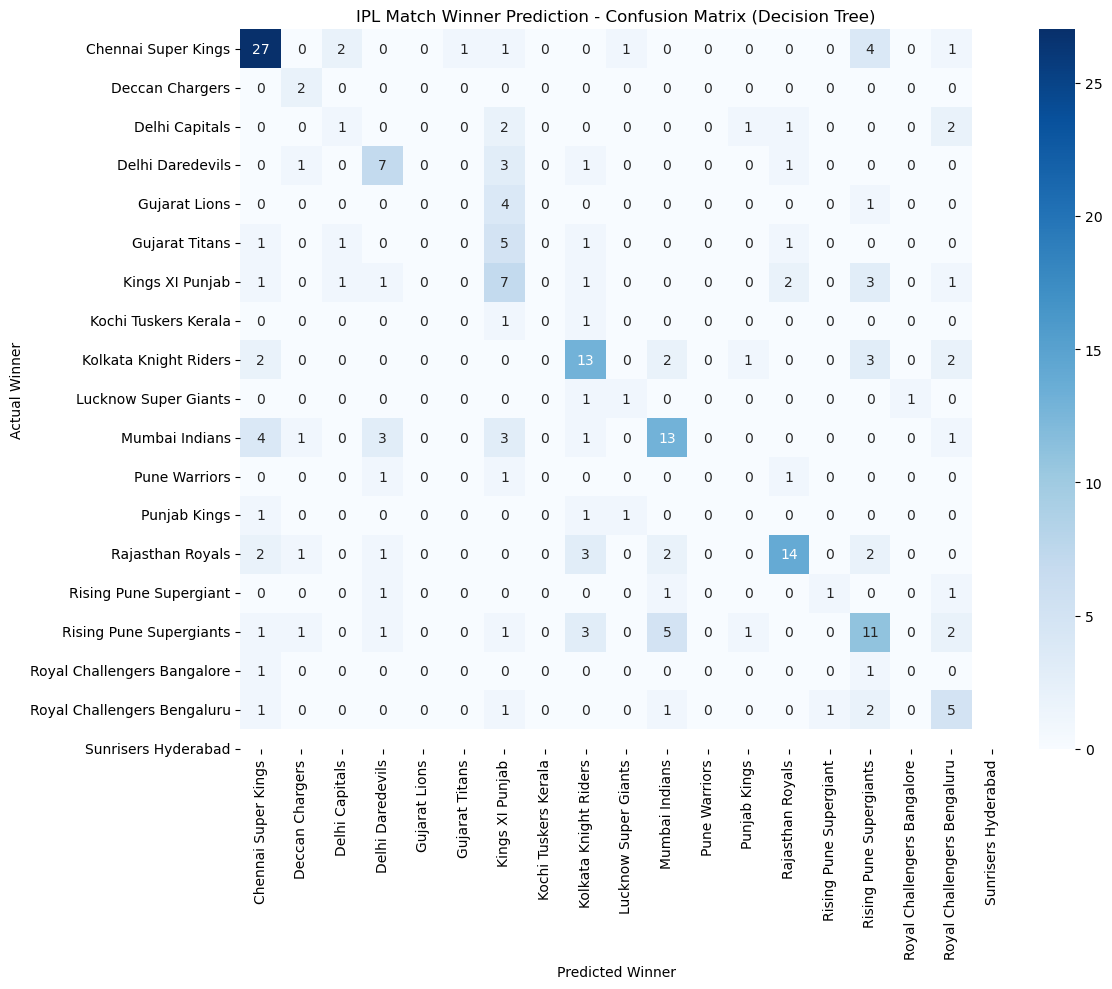

In [24]:
# Show sample confusion matrix and classification report for the Decision Tree model
print("\n--- Decision Tree Classification Report ---")
print(classification_report(y_test, dt_preds, labels=list(range(len(encoders['match_winner'].classes_))), target_names=encoders['match_winner'].classes_, zero_division=0))

# Plot Confusion Matrix for Decision Tree model
cm = confusion_matrix(y_test, dt_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=encoders['match_winner'].classes_, 
            yticklabels=encoders['match_winner'].classes_)
plt.title('IPL Match Winner Prediction - Confusion Matrix (Decision Tree)')
plt.xlabel('Predicted Winner')
plt.ylabel('Actual Winner')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()